##Bài 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sentences = [
    "My name is Sang",
    "My nickname is Blan",
    "I am studying at UIT",
    "Ronaldo is GOAT",
    "Portugal will win World Cup 2026",
    "My favourite sport is badminton",
    "I am currently studying a Machine Learning course from HCMUT",
    "I love tiktok"
]

In [3]:
vocab = sorted(set(
    word
    for sentence in sentences
    for word in sentence.lower().split()
))
print(vocab)

['2026', 'a', 'am', 'at', 'badminton', 'blan', 'course', 'cup', 'currently', 'favourite', 'from', 'goat', 'hcmut', 'i', 'is', 'learning', 'love', 'machine', 'my', 'name', 'nickname', 'portugal', 'ronaldo', 'sang', 'sport', 'studying', 'tiktok', 'uit', 'will', 'win', 'world']


In [4]:
def to_vector(sentence):
    vector = np.zeros(len(vocab))
    for word in sentence.lower().split():
        index = vocab.index(word)
        vector[index] += 1
    return vector

In [5]:
X = np.array([to_vector(s) for s in sentences])
print(X)
print("Shape:", X.shape)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1.
  0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0.
  0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 1. 0. 0. 0. 0.]]
Shape: (8, 31)


In [6]:
mean_vector = X.mean(axis=0)
print(mean_vector.shape)
X_centered = X - mean_vector
print(X_centered.shape)

(31,)
(8, 31)


In [7]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    Y_norm = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return X_norm @ Y_norm.T

In [8]:
similarity = cosine_similarity(X)
print(similarity)

[[1.         0.5        0.         0.28867513 0.         0.4472136
  0.         0.        ]
 [0.5        1.         0.         0.28867513 0.         0.4472136
  0.         0.        ]
 [0.         0.         1.         0.         0.         0.
  0.42426407 0.25819889]
 [0.28867513 0.28867513 0.         1.         0.         0.25819889
  0.         0.        ]
 [0.         0.         0.         0.         1.         0.
  0.         0.        ]
 [0.4472136  0.4472136  0.         0.25819889 0.         1.
  0.         0.        ]
 [0.         0.         0.42426407 0.         0.         0.
  1.         0.18257419]
 [0.         0.         0.25819889 0.         0.         0.
  0.18257419 1.        ]]


In [9]:
def search(query, top_k=3):
    query_vector = to_vector(query)
    scores = cosine_similarity(
        query_vector.reshape(1,-1),
        X
    )[0]
    index = np.argsort(scores)[::-1]
    for i in index[:top_k]:
        print(sentences[i])
        print("Score:", round(scores[i],3))
        print()

In [13]:
search("Ronaldo")

Ronaldo is GOAT
Score: 0.577

I love tiktok
Score: 0.0

My favourite sport is badminton
Score: 0.0



In [14]:
similarity = cosine_similarity(X)
np.fill_diagonal(similarity,-1)
best = np.unravel_index(np.argmax(similarity), similarity.shape)
print(best)
print(sentences[best[0]])
print(sentences[best[1]])

(np.int64(0), np.int64(1))
My name is Sang
My nickname is Blan


In [15]:
worst = np.unravel_index(np.argmin(similarity), similarity.shape)
print(worst)
print(sentences[worst[0]])
print(sentences[worst[1]])

(np.int64(0), np.int64(0))
My name is Sang
My name is Sang


##Bài 2

In [17]:
X_centered = X - X.mean(axis=0)

In [18]:
U,S,Vt = np.linalg.svd(
    X_centered,
    full_matrices=False
)

In [19]:
coords = U[:,:2] * S[:2]

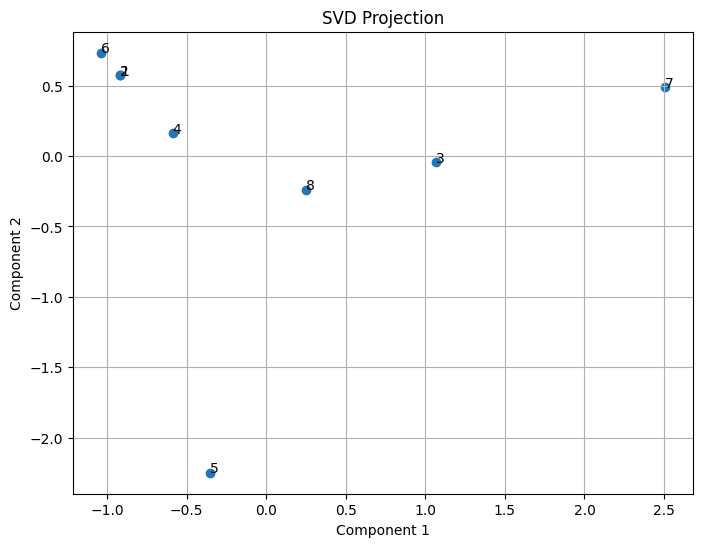

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(coords[:,0], coords[:,1])
for i in range(len(sentences)):
    plt.text(
        coords[i,0],
        coords[i,1],
        str(i+1)
    )
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("SVD Projection")
plt.grid(True)
plt.show()

In [22]:
for i,s in enumerate(sentences):
    print(i+1, s)

1 My name is Sang
2 My nickname is Blan
3 I am studying at UIT
4 Ronaldo is GOAT
5 Portugal will win World Cup 2026
6 My favourite sport is badminton
7 I am currently studying a Machine Learning course from HCMUT
8 I love tiktok
